# Tilpasning af firparameter-logistisk dosis-respons-kurve med PROC NLIN

## Sammenfatning

Denne notebook tilpasser en firparameter-logistisk (4PL) dosis-respons-model til et syntetisk cellebaseret potens-bioassay ved hjælp af **PROC NLIN** og estimerer den nedre og øvre asymptote, EC50 (den halvt-maksimale effektive koncentration) og Hill-hældningen. 4PL er standardmodellen (arbejdshesten) for relativ-potens-assays i lægemiddeludvikling, og notebooken gennemgår modelspecifikation, parameterafgrænsning, konvergensdiagnostik og påtegning af den tilpassede sigmoide på de observerede koncentrations-respons-data.

## Datakilder

Notebooken genererer ét syntetisk datasæt inline; ingen ekstern input eller netværksinput anvendes.

**`assay` — syntetisk cellebaseret potens-bioassay (24 rækker)**

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `lot` | num | Lægemiddelstof-lot (1-3); tre replikatkørsler af fortyndingsrækken |
| `dose` | num | Stofkoncentration i nmol/L på tværs af en 8-punkts seriefortynding (0.1 til ~1000) |
| `logdose` | num | 10-tals-logaritmen af `dose`, brugt til at plotte på den konventionelle log-koncentrationsakse |
| `response` | num | Målt assay-signal (procent af maksimal respons), genereret ud fra en sand 4PL-kurve (bund=5, top=100, EC50=25 nmol/L, Hill-hældning=1.2) plus proportional Gaussisk støj |

De sande genererende parametre er indbygget i DATA step, så de genfundne NLIN-estimater kan sammenholdes med den kendte sandhed.

# Firparameter-logistisk dosis-respons-tilpasning

I farmaceutiske potens- og bioaktivitets-assays er forholdet mellem stofkoncentration og målt respons karakteristisk sigmoidt på en log-koncentrationsskala. Den **firparameter-logistiske (4PL)** model er standardværktøjet til at opsummere sådanne kurver:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

hvor

- **A** = nedre asymptote (respons ved uendelig fortynding / baseline-signal),
- **D** = øvre asymptote (maksimal respons ved mættende koncentration),
- **C** = **EC50**, den koncentration der giver den halvt-maksimale respons (inflektionspunktet og den primære potens-aflæsning),
- **B** = **Hill-hældningen**, der styrer overgangens stejlhed.

Denne model er ulineær i sine parametre, så vi tilpasser den med iterativ mindste kvadraters metode ved hjælp af `PROC NLIN`. Nedenfor simulerer vi en realistisk otte-punkts fortyndingsrække kørt i triplikat, tilpasser 4PL-kurven, afgrænser parametrene til fysisk meningsfulde områder, inspicerer konvergens- og tilpasningsdiagnostik og påtegner den tilpassede kurve på dataene.

## Trin 1 — Simulér et cellebaseret potens-bioassay

Vi genererer et syntetisk datasæt ud fra en *kendt* 4PL-kurve (bund = 5, top = 100, EC50 = 25 nmol/L, Hill-hældning = 1.2), så de parametre NLIN genfinder, kan kontrolleres mod den sande værdi. Tre lots modtager hver den samme otte-punkts seriefortynding (hvert trin en 3.5-fold fortynding) med proportional Gaussisk målestøj lagt ovenpå. Et fast `streaminit`-seed gør simuleringen reproducerbar.

In [1]:
data assay;
    CALL streaminit(40521);

    /* Sande 4PL-parametre brugt til at generere dataene */
    A_true   = 5;      /* nedre asymptote (baseline)        */
    D_true   = 100;    /* øvre asymptote (maks. respons)   */
    C_true   = 25;     /* EC50 i nmol/L                      */
    B_true   = 1.2;    /* Hill-hældning                       */

    GØR lot = 1 TIL 3;
        /* Otte-punkts seriefortynding, 3.5-fold trin */
        dose = 0.30;
        GØR point = 1 TIL 8;
            dose = dose * 3.5;

            /* Støjfri 4PL-middelrespons */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportional + additiv Gaussisk assay-støj */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            UDDATA;
        SLUT;
    SLUT;

    BEHOLD lot dose logdose response;
KØR;

PROCEDURE SORTER data=assay;
    EFTER dose lot;
KØR;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Trin 2 — Visualisér de rå koncentrations-respons-data

Før tilpasning plotter vi respons mod log10(dose) for at bekræfte den forventede sigmoide form og for at aflæse grove startværdier: kurven bunder nær 5, planer ud nær 100, og midtpunktet (den halvt-maksimale respons) ligger omkring log10(25) ≈ 1.4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


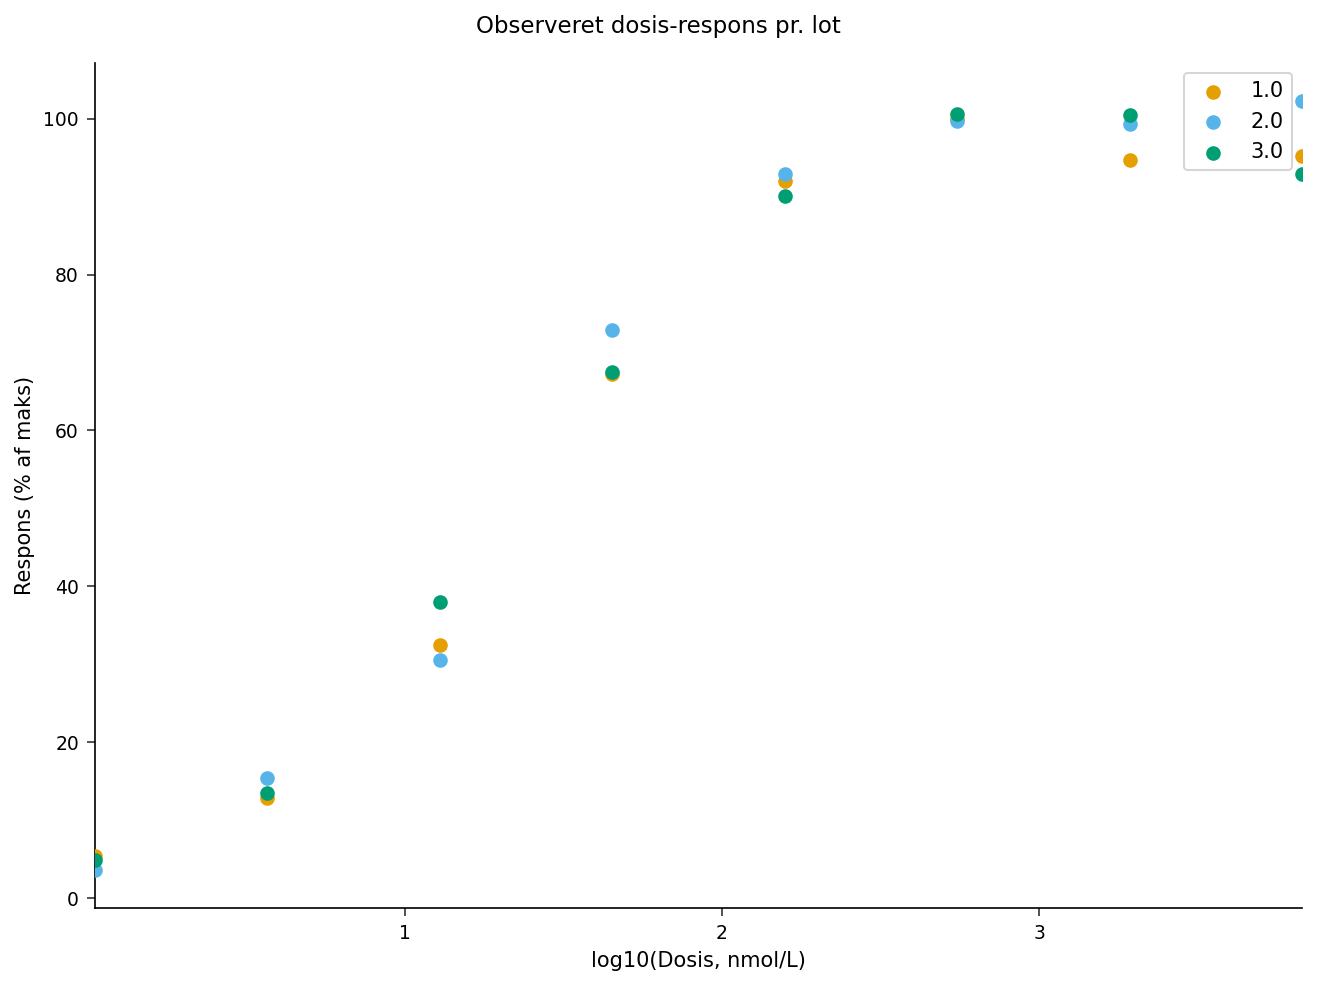

In [2]:
PROCEDURE SGPLOT data=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS MÆRKAT='log10(Dosis, nmol/L)';
    YAXIS MÆRKAT='Respons (% af maks)';
    TITEL 'Observeret dosis-respons pr. lot';
KØR;
TITEL;


## Trin 3 — Tilpas 4PL-modellen med PROC NLIN

Vi angiver startværdier med `PARMS` (informeret af spredningsdiagrammet), definerer 4PL-middelværdien i en mellemliggende tildeling og videregiver den til `MODEL`-sætningen. Fysisk meningsfulde `BOUNDS` holder asymptoterne ordnede og EC50 og hældning positive, hvilket stabiliserer Gauss-Newton-iterationerne. `OUTPUT`-sætningen gemmer prædikterede værdier, residualer og konfidensgrænser til senere diagnostik, og `PLOTS=` anmoder om tilpasnings- og diagnostikpanelerne.

In [3]:
PROCEDURE nlin data=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Hold parametrene i fysisk meningsfulde områder */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Firparameter-logistisk middelrespons (indlejret: Jenner PROC NLIN
       understøtter endnu ikke at referere til en mellemliggende
       programstatement-variabel i MODEL -- se tests/400986 -- så vi
       indlejrer nævneren) */
    MODEL response = D + (A - D) / (1 + (dose / C) ** B);

    UDDATA out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
KØR;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/15fa70a0-aaff-4758-8bba-90bc2c6c673f/fit4pl.avro


## Trin 4 — Rapportér den estimerede EC50 og kurvekarakteristika

`OUTEST=`-mekanismen er praktisk, men for en hurtig potens-aflæsning opsummerer vi den tilpassede kurve direkte. Her oplister vi de tilpassede værdier ved hver dosis sammen med de observerede responser for at bekræfte, at modellen følger dataene over hele fortyndingsområdet.

In [4]:
PROCEDURE GENNEMSNIT data=fit4pl mean std MIN MAX maxdec=3;
    KLASSE dose;
    VARIABEL response pred resid;
    TITEL 'Observeret vs. tilpasset respons pr. dosis';
KØR;
TITEL;


                                       Observeret vs. tilpasset respons pr. dosis                                       

                                                  The MEANS Procedure

                                             Analysis Variable : RESPONSE

                                           N
                       dose              Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.393
        


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Trin 5 — Påtegn den tilpassede 4PL-kurve på de observerede data

Et tæt prædiktionsgitter giver en glat tilpasset sigmoide. Vi kombinerer den glatte kurve med de dosis-vise middel-tilpassede værdier og konfidensbåndet og påtegner derefter det hele på de observerede punkter for visuelt at vurdere tilpasningens godhed.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


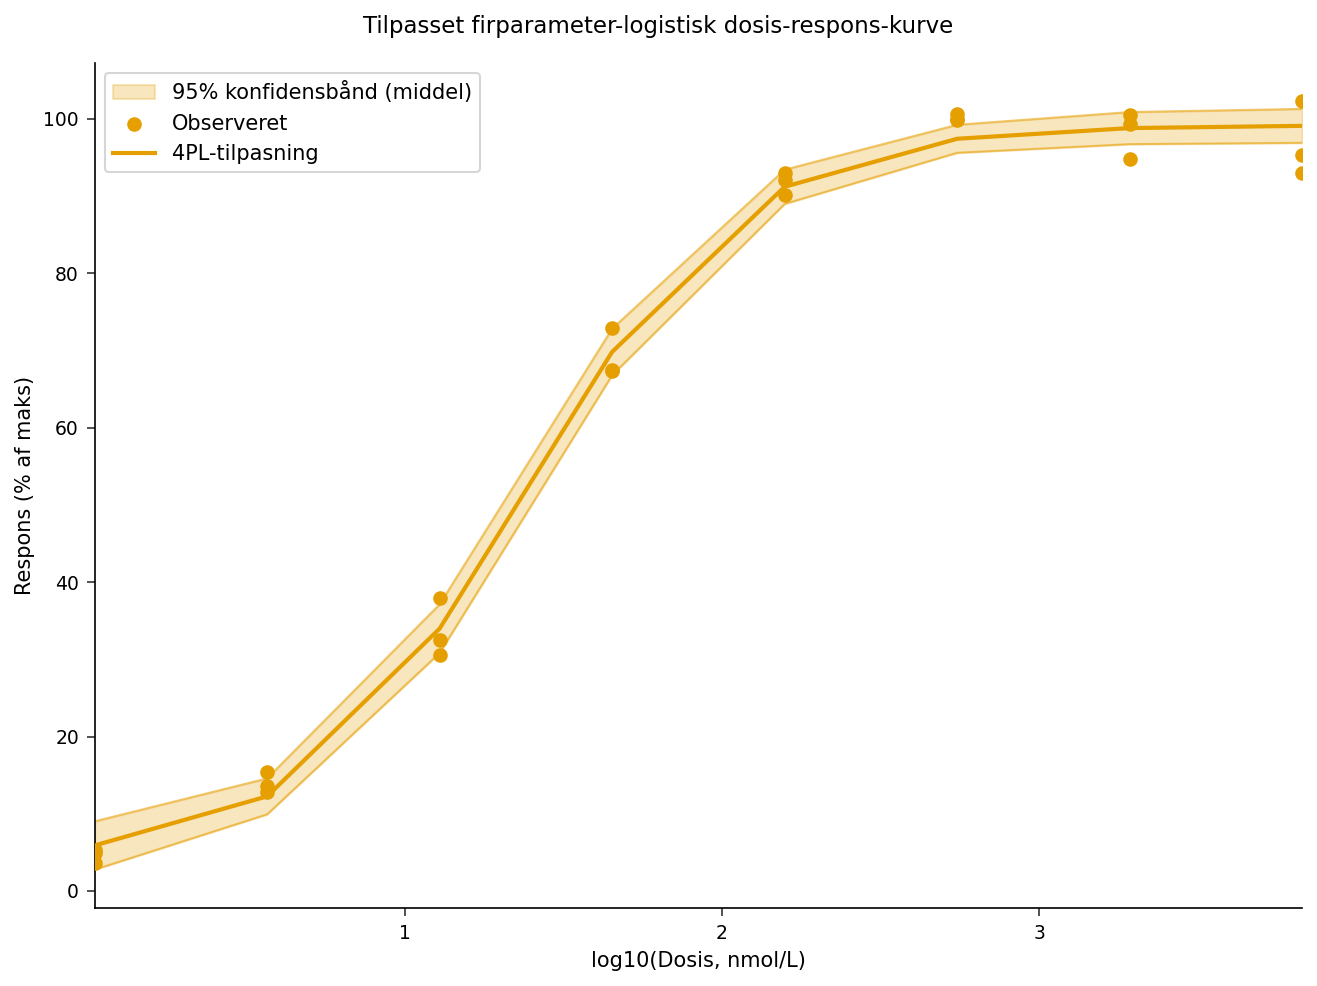

In [5]:
PROCEDURE SORTER data=fit4pl;
    EFTER logdose;
KØR;

PROCEDURE SGPLOT data=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% konfidensbånd (middel)';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Observeret';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='4PL-tilpasning';
    XAXIS MÆRKAT='log10(Dosis, nmol/L)';
    YAXIS MÆRKAT='Respons (% af maks)';
    TITEL 'Tilpasset firparameter-logistisk dosis-respons-kurve';
KØR;
TITEL;


## Fortolkning af resultaterne

`PROC NLIN` konvergerer til estimater tæt på de kendte genererende værdier: en nedre asymptote nær **5**, en øvre asymptote nær **100**, en **EC50 (C)** nær **25 nmol/L** og en **Hill-hældning (B)** nær **1.2**. Genfindingen af disse parametre ud fra støjfyldte triplikatdata bekræfter, at modellen er identificerbar, og at grænserne ikke var bindende i optimum.

**EC50** er det centrale potens-mål: lavere værdier indikerer et mere potent stof, og i et relativ-potens-assay sammenlignes EC50 for et testlot med en referencestandard. **Hill-hældningen** karakteriserer kooperativitet og assayets stejlhed — en hældning nær 1 er forenelig med simpel enkelt-sæde-binding. **Asymptoterne** definerer assayets dynamiske område; en stabil, veladskilt bund og top er forudsætninger for et validerbart bioassay.

Tilpasningsplottet viser sigmoiden gå gennem skyen af observerede punkter med et smalt 95% middel-konfidensbånd gennem det responsive område, og residualdiagnostikken bør ikke vise nogen systematisk krumning — hvilket er tegn på, at 4PL-formen er tilstrækkelig. I praksis ville man udvide denne arbejdsgang med `PROFILE`-likelihood-intervaller for EC50, en `BOOTSTRAP`-sætning for fordelingsfri parameterinferens eller en parallel-linje-analyse, der sammenligner test- og referencelots for at estimere relativ potens.